# Lecture 2 - Gradient Descent

## Reminders
- How do we find the global minima and maxima of a given real-values function $f(x)$?
    - We find derivatives, where $f'(x)=0$ and where $f'(x)$ DNE (does not exist).
    - This shows that we want *differentiable activation functions*

- What if the derivative is difficult to compute or the derivative is not existent? That is, we have only data and no actual $f(x)$?
    - We need to estimate $f'$ - which requires cleverness from human side. Out of scope of this class (covered in MATH470/471)

## Fundemental Idea behind Gradient Descent

Steepest descent (looking at pathway of steepest descent).

### Mathematical Approach

To find the (global) minimum, we move iteratively (step-wise) in the direction of steepest descent. 

We need two additional concepts to create an iterative process:

1. An initial position $x_0$
2. AN iterative/recursive rule to determine $x_n+1$ from previous $x_i$'s.

For gradient descent, looked at rule.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.ticker import MaxNLocator
from itertools import product

In [ ]:
def f(x):
    return x**2 - 2*x - 3
def fprime(x):
    return 2*x - 2

In [ ]:
# Making a simple routie for plot function with simple line chart
x = np.linspace(-4, 4, 100)
y = f(x)

def plotFunc(x0, func):
    plt.figure(figsize=(8, 5))
    plt.plot(x0, func(x0), label='f(x)')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.title('Plot of f(x)')
    plt.grid(True)
    plt.legend()
    plt.show()
    
def plotPath(xs, ys, x0, func):
    plotFunc(x0, func)
    plt.plot(xs, ys, linestyle = '--', color = 'orange')
    plt.plot(xs[-1], ys[-1], 'ro')

In [ ]:
def GradientDescent1D(func, fprime, x0, alpha, tol = 1e-5, max_iter = 1000, verbose = False):
    # Init cur x-value (xk), f(xk), and -f'(xk)
    xk = x0
    fk = func(xk)
    pk = fprime(xk)
    
    # Initialize number of steps and lists of x- and y-coordinates
    num_iter = 1
    coord_x = [ xk ]
    coord_y = [ fk ]
    
    # Loop until the 1d gradient (derivative) is close to 0 (the error tolerance is met), or we reach max num of iters
    while ( abs(pk) > tol and num_iter < max_iter + 1 ):
        
        # Calculate new xk, f(xk), and -f'(xk)  (here is our actual gradient descent)
        xk = xk - alpha * pk
        fk = func(xk)
        pk = fprime(xk)
        
        if verbose:
            print('Iteration {}: x-cood: {}, y-coord {}, gradf(x): {}'.format(num_iter, xk, fk, pk))
            
        # Record latest coordiantes
        coord_x.append(xk)
        coord_y.append(fk)
        
        # Increment counter
        num_iter += 1
        
    # Print results to console
    if num_iter == max_iter + 1:
        print('gradient descent does not converge')
    else:
        print('Solution found:\n  y = {:.4f}\n  x = {:.4f}'.format(fk, xk))
        
    # Return lists of coordinates
    return ( coord_x, coord_y )  # NOTE: GOOD ENGINEERING HAS ONLY ONE RETURN POINT (security/debugging/stability)
        

Iteration 1: x-cood: -0.12000000000000005, y-coord -2.7456, gradf(x): -2.24
Iteration 2: x-cood: 0.10399999999999998, y-coord -3.197184, gradf(x): -1.792
Iteration 3: x-cood: 0.2832, y-coord -3.48619776, gradf(x): -1.4336
Iteration 4: x-cood: 0.42656000000000005, y-coord -3.6711665664, gradf(x): -1.14688
Iteration 5: x-cood: 0.5412480000000001, y-coord -3.7895466024960003, gradf(x): -0.9175039999999999
Iteration 6: x-cood: 0.6329984000000001, y-coord -3.86530982559744, gradf(x): -0.7340031999999999
Iteration 7: x-cood: 0.70639872, y-coord -3.9137982883823614, gradf(x): -0.5872025599999999
Iteration 8: x-cood: 0.765118976, y-coord -3.9448309045647116, gradf(x): -0.469762048
Iteration 9: x-cood: 0.8120951808, y-coord -3.9646917789214156, gradf(x): -0.37580963840000003
Iteration 10: x-cood: 0.84967614464, y-coord -3.977402738509706, gradf(x): -0.30064771072000007
Iteration 11: x-cood: 0.879740915712, y-coord -3.985537752646212, gradf(x): -0.24051816857600006
Iteration 12: x-cood: 0.903792

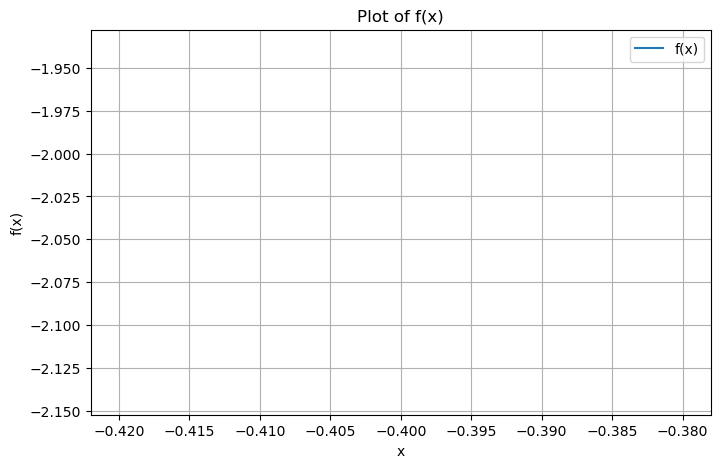

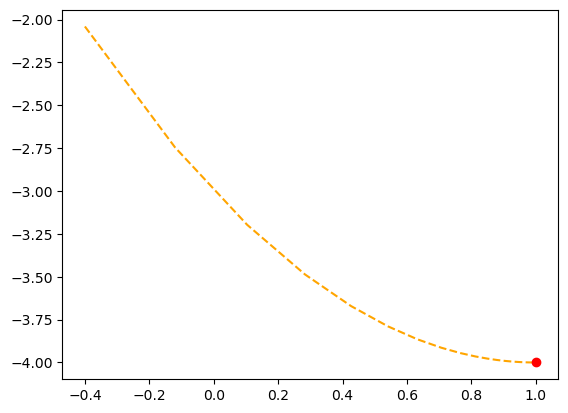

In [ ]:
x0 = -0.4
xs, ys = GradientDescent1D(f, fprime, x0, alpha=0.1, verbose=True)
plotPath(xs, ys, x0, f)

## Gradient Descent in Higher Dimensions

$n$-dimensional Griewank Function.

Reviewed partial derivatives

### Partial Derivatives: Essential Idea of Implementation

In practice, when using the definition $\frac{}{}$... . Went over example.

Let $f(x, y, z) = x^3 y + y^3 z - \cos(xyz)$. Try and solve the partial derivatives.

Definition of Gradient $\nabla f$, $\nabla G$
 
KDEs vs PDEs (briefly talkled about, should look into. We don't understand alot of this as a species). Deep learning attemps to simulate PDEs.

$G(x, y)$ can also be written in column vector form.

In [ ]:
import numpy as np
def GradientDescent2D(f, gradf, x0, alpha=.1, tol = 1e-5, max_iter = 1000, verbose = False):
    # Init cur x-value (xk), f(xk), and -f'(xk)
    xk = np.array(x0)
    fk = f(xk)
    gfk = gradf(xk)
    gfk_norm = np.linalg.norm(gfk)  # Takes all vector components, squares them, then takes the square root (boils all down to a single number)
    
    # Initialize number of steps and lists of x- and y-coordinates
    num_iter = 1
    coord_xy = [ xk ]
    coord_y = [ fk ]
    
    # Loop until the 1d gradient (derivative) is close to 0 (the error tolerance is met), or we reach max num of iters
    while ( gfk_norm > tol and num_iter < max_iter + 1 ):
        
        # Calculate new xk, f(xk), and -f'(xk)  (here is our actual gradient descent)
        xk = xk - alpha * gfk
        fk = f(xk)
        gfk = gradf(xk)
        gfk_norm = np.linalg.norm(gfk)
        
        # Record latest coordiantes
        coord_x.append(xk[0])
        coord_y.append(xk[1])
        
        # Increment counter
        num_iter += 1
        
    # Print results to console
    if num_iter == max_iter + 1:
        print('gradient descent does not converge')
    else:
        print('Solution found:\n  y = {:.4f}\n  x = ({:.4f}, {:.4f})'.format(fk, xk[0], xk[1]))
        
    # Return lists of coordinates
    return ( coord_x, coord_y )  # NOTE: GOOD ENGINEERING HAS ONLY ONE RETURN POINT (security/debugging/stability)

In [ ]:
# NOTE

# Establish 2d domain
x1 = np.array([ [0], [3] ])

For HW, gradient descent al -> 1d/2d, 3d surface countour plot 3d

In [ ]:
# Countour plot of 3d surface function, with Gradient Descent Path
# NOT REALLY CHECKED TOO MUCH

### Lecture Continued - Gradient Descent II - 10/13/25

Today, we will look at applying GD (gradient descent) on a cost function (mse - mean squared error)

## Linear Regression + Gradient Descent

This can be a very fast function. 

$y_\text{pred}(x_i) = mx_i + b$

m and b are parameters (or weights), where *m* is the slope of the model and *b* is the y-intercept.

One mechanis to minize the error between our model and the actual data is MSE (Mean Squared Error).

We can use MSE as our cost function for the linear model, and then apply Gradient Descent.

Given that we have *m* and *b*, we can place these in a vector and take the partial derivative 


The gradient descent will try and optimize the parameters of this line to get the best fit to the training, using MSE as a heuritstic kind of.

Cool graph/map gradient descent onto 3d.